In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, GlobalAveragePooling2D, Dense, Multiply, Add, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K


In [ ]:

# -----------------------------------------
# 🔹 Load Dataset from Google Drive
# -----------------------------------------

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5
INPUT_SHAPE = (224, 224, 3)
DATASET_PATH = '/content/drive/MyDrive/Pie_berry'  # Change as needed
MODEL_SAVE_PATH = 'best_model.h5'
SEED = 42  # or any number


train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True ,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False ,
    seed=SEED
)


Found 2016 images belonging to 5 classes.
Found 503 images belonging to 5 classes.


In [ ]:
# -----------------------------------------
# 🔹 Define Multi-Branch Lightweight CNN with Attention
# -----------------------------------------
# 🧠 Attention Module
def attention_module(inputs):
    channel = K.int_shape(inputs)[-1]
    x = GlobalAveragePooling2D()(inputs)
    x = Dense(channel // 8, activation='relu')(x)
    x = Dense(channel, activation='sigmoid')(x)
    x = tf.keras.layers.Reshape((1, 1, channel))(x)
    return Multiply()([inputs, x])

# 🧠 Dual-branch CNN model
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # Branch 1
    x1 = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.3)(x1)
    x1 = attention_module(x1)

    # Branch 2
    x2 = Conv2D(32, (5, 5), padding='same', activation='relu')(inputs)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.3)(x2)
    x2 = attention_module(x2)

    # Merge
    merged = Concatenate()([x1, x2])

    x = Conv2D(64, (3, 3), padding='same', activation='relu', name='last_conv')(merged)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

model = build_model(INPUT_SHAPE, NUM_CLASSES)
optimizer = Adam(
    learning_rate=0.0003,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# 🧠 Callbacks
callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=3, factor=0.3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor='val_accuracy', verbose=1)
]

# Model Summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 224, 224, 32)   │            896 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 224, 224, 32)   │          2,432 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 224, 224, 32)   │            128 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 224, 224, 32)   │            128 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 224, 224, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 224, 224, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 32)             │              0 │ dropout[0][0]          │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 32)             │              0 │ dropout_1[0][0]        │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 4)              │            132 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 4)              │            132 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 32)             │            160 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 32)             │            160 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 32)       │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 1, 1, 32)       │              0 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 224, 224, 32)   │              0 │ dropout[0][0],         │
│                           │                        │                │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)

 Total params: 41,677 (162.80 KB)

 Trainable params: 41,421 (161.80 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# -----------------------------------------
# 🔹 Train the Model
# -----------------------------------------
# 🚀 Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5019 - loss: 1.2391
Epoch 1: val_accuracy improved from -inf to 0.35189, saving model to best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 707s 11s/step - accuracy: 0.5033 - loss: 1.2362 - val_accuracy: 0.3519 - val_loss: 1.5532 - learning_rate: 3.0000e-04
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.6914 - loss: 0.8366
Epoch 2: val_accuracy did not improve from 0.35189
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 550ms/step - accuracy: 0.6916 - loss: 0.8363 - val_accuracy: 0.2366 - val_loss: 1.5070 - learning_rate: 3.0000e-04
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.7349 - loss: 0.7490
Epoch 3: val_accuracy did not improve from 0.35189
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 548ms/step - accuracy: 0.7347 - loss: 0.7491 - val_accuracy: 0.2286 - val_loss: 1.4404 - learning_rate: 3.0000e-04
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.7707 - loss: 0.6715
Epoch 4: val_accuracy did not improve from 0.35189
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 556ms/step - accuracy: 0.7706 - loss: 0.6717 - val_accuracy: 0.2922 - val_loss: 1.3660 - learning_rate: 3.0000e-04
Epoch 

63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 557ms/step - accuracy: 0.7911 - loss: 0.6174 - val_accuracy: 0.4433 - val_loss: 1.1368 - learning_rate: 3.0000e-04
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.8024 - loss: 0.5846
Epoch 7: val_accuracy improved from 0.44334 to 0.51292, saving model to best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 545ms/step - accuracy: 0.8023 - loss: 0.5847 - val_accuracy: 0.5129 - val_loss: 1.0547 - learning_rate: 3.0000e-04
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.8196 - loss: 0.5481
Epoch 8: val_accuracy improved from 0.51292 to 0.69781, saving model to best_model.h5


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 542ms/step - accuracy: 0.8685 - loss: 0.3699 - val_accuracy: 0.8767 - val_loss: 0.3858 - learning_rate: 9.0000e-05
Epoch 22/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.8749 - loss: 0.3837
Epoch 22: val_accuracy improved from 0.87674 to 0.88270, saving model to best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 561ms/step - accuracy: 0.8749 - loss: 0.3836 - val_accuracy: 0.8827 - val_loss: 0.3852 - learning_rate: 9.0000e-05
Epoch 23/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.8713 - loss: 0.3807
Epoch 23: val_accuracy improved from 0.88270 to 0.89066, saving model to best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 561ms/step - accuracy: 0.8713 - loss: 0.3807 - val_accuracy: 0.8907 - val_loss: 0.3786 - learning_rate: 9.0000e-05
Epoch 24/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.8784 - loss: 0.3565
Epoch 24: val_accuracy did not improve from 0.89066
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 567ms/step - accuracy: 0.8783 - loss: 0.3566 - val_accuracy: 0.8847 - val_loss: 0.3766 - learning_rate: 9.0000e-05
Epoch 25/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8670 - loss: 0.3757
Epoch 25: val_accuracy did not improve from 0.89066
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 539ms/step - accuracy: 0.8671 - loss: 0.3756 - val_accuracy: 0.8827 - val_loss: 0.3683 - learning_rate: 9.0000e-05
Epoch 26/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.8775 - loss: 0.3651
Epoch 26: val_accuracy improved from 0.89066 to 0.90258, saving model to best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 563ms/step - accuracy: 0.8773 - loss: 0.3653 - val_accuracy: 0.9026 - val_loss: 0.3559 - learning_rate: 9.0000e-05
Epoch 27/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.8864 - loss: 0.3513
Epoch 27: val_accuracy did not improve from 0.90258
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 548ms/step - accuracy: 0.8863 - loss: 0.3515 - val_accuracy: 0.8728 - val_loss: 0.3830 - learning_rate: 9.0000e-05
Epoch 28/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8745 - loss: 0.3791
Epoch 28: val_accuracy did not improve from 0.90258
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 554ms/step - accuracy: 0.8745 - loss: 0.3789 - val_accuracy: 0.8807 - val_loss: 0.3637 - learning_rate: 9.0000e-05
Epoch 29/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.8786 - loss: 0.3523
Epoch 29: val_accuracy did not improve from 0.90258
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 562ms/step - accuracy: 0.8786 - loss: 0.3525 - val_accuracy: 0.8907 - val_loss: 0.3547 - learning_rate: 9.0000e-05

63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 561ms/step - accuracy: 0.8867 - loss: 0.3364 - val_accuracy: 0.9046 - val_loss: 0.3446 - learning_rate: 2.7000e-05
Epoch 36/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.8860 - loss: 0.3487
Epoch 36: val_accuracy did not improve from 0.90457
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 538ms/step - accuracy: 0.8860 - loss: 0.3486 - val_accuracy: 0.8986 - val_loss: 0.3494 - learning_rate: 2.7000e-05
Epoch 37/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8793 - loss: 0.3568
Epoch 37: val_accuracy did not improve from 0.90457
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 558ms/step - accuracy: 0.8794 - loss: 0.3566 - val_accuracy: 0.8926 - val_loss: 0.3486 - learning_rate: 2.7000e-05
Epoch 38/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8786 - loss: 0.3473
Epoch 38: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.

Epoch 38: val_accuracy did not improve from 0.90457
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 543ms/step - accuracy: 0.8788 - loss

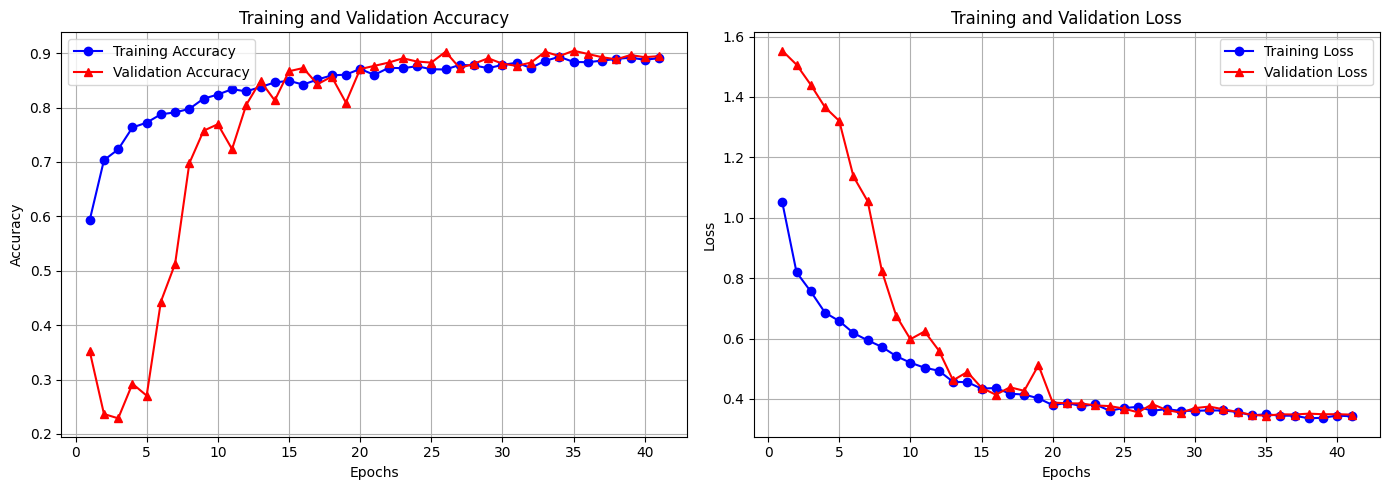

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 📈 Plot Accuracy and Loss Graphs
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r^-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r^-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [ ]:
# -----------------------------------------
# 🔹 Evaluate Model using Confusion Matrix & Classification Report
# -----------------------------------------
# 🔍 Get predictions for the validation set
val_generator.reset()
preds = model.predict(val_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step


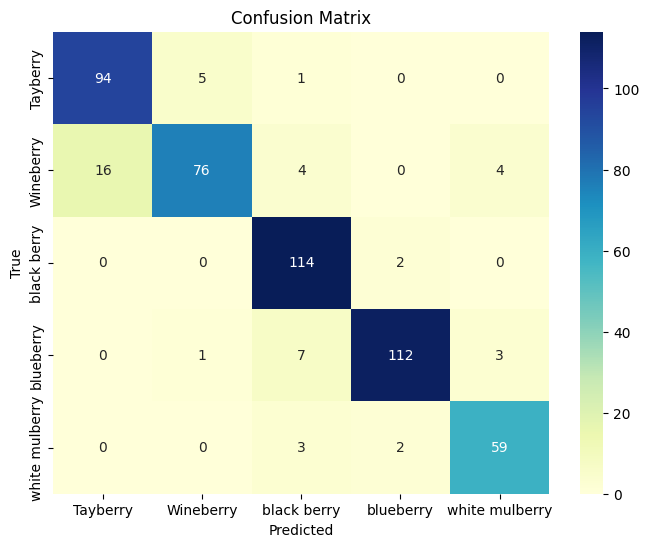

Classification Report:

                precision    recall  f1-score   support

      Tayberry       0.85      0.94      0.90       100
     Wineberry       0.93      0.76      0.84       100
   black berry       0.88      0.98      0.93       116
     blueberry       0.97      0.91      0.94       123
white mulberry       0.89      0.92      0.91        64

      accuracy                           0.90       503
     macro avg       0.90      0.90      0.90       503
  weighted avg       0.91      0.90      0.90       503



In [ ]:

# 📊 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 📄 Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n")
print(report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step


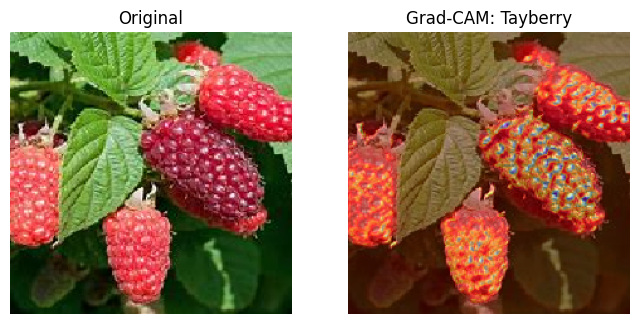

In [ ]:
# 🧠 Load the trained model (in case you run Grad-CAM later)
model = load_model(MODEL_SAVE_PATH)

# 🟨 Grad-CAM Implementation
def generate_gradcam(model, img_array, class_index, last_conv_layer_name="last_conv"):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap + tf.keras.backend.epsilon())

    return heatmap.numpy()

# 🔎 Visualize Grad-CAM
def display_gradcam(img_path, model, class_labels):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    input_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(input_array)
    class_idx = np.argmax(preds)

    heatmap = generate_gradcam(model, input_array, class_idx)

    # Convert to heatmap
    heatmap = cv2.resize(heatmap, IMAGE_SIZE)
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose heatmap on image
    img_np = np.uint8(255 * img_array)
    superimposed = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img_np)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Grad-CAM: {class_labels[class_idx]}")
    plt.imshow(superimposed)
    plt.axis('off')
    plt.show()

# 📸 Example Usage (Change path & class labels accordingly)
class_labels = list(train_generator.class_indices.keys())
img_path = '/content/drive/MyDrive/Pie_berry/Tayberry/1.jpg'  # Replace with your image path
display_gradcam(img_path, model, class_labels)

In [ ]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 27.9 MB/s eta 0:00:00


In [ ]:
import visualkeras
from PIL import ImageFont

# Load default font
font = ImageFont.load_default()

# Generate the model visualization
image = visualkeras.layered_view(model, legend=True, font=font)

# Resize the image if needed (e.g., make it larger)
image = image.resize((1000, 800))  # Change width & height as needed

image.show()

image.save("model_architecture.png")

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")
